## Explore NYC Noise Patterns (Summer)
This is an exploration of a **typical summer day** NYC 311 noise complaints using the pre-aggregated PUMA/NTA feature table. The purpose 
is to get an intuitive sense of noise complaints within the city.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API", category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Load + prepare data: 2021 - 2024

In [2]:
from helpers import prep_the_data

df_puma = pd.read_parquet("../data/processed/features/puma_noise_counts.parquet")
df_puma = prep_the_data(df_puma)

# Ensure datetime once (upstream helpers may already do this, but keep it explicit)
df_puma["created_bucket"] = pd.to_datetime(df_puma["created_bucket"])
df_puma.head()


/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


,puma,complaint_type,descriptor,location_type,created_bucket,time_of_day,complaint_count,nta,area_share_of_puma,nta_name,nta_puma,dow,month,is_weekend,month_year,descriptor_group,dow_complaint
0,4103,Noise,Noise,NR5,2022-06-09,day,1,MN0303,0.403905,East Village,East Village — 4103,Thursday,June,0,June__2022,Other,OTHER__Thursday
1,4103,Noise,"Noise, Barking Dog",NaN,2021-07-10,night,1,MN0303,0.403905,East Village,East Village — 4103,Saturday,July,1,July__2021,Animal,ANIMAL__Saturday
2,4103,Noise,"Noise, Barking Dog",NaN,2021-08-07,day,1,MN0303,0.403905,East Village,East Village — 4103,Saturday,August,1,August__2021,Animal,ANIMAL__Saturday
3,4103,Noise,"Noise, Barking Dog",NaN,2021-08-13,day,1,MN0303,0.403905,East Village,East Village — 4103,Friday,August,0,August__2021,Animal,ANIMAL__Friday
4,4103,Noise,"Noise, Barking Dog",NaN,2021-08-15,night,2,MN0303,0.403905,East Village,East Village — 4103,Sunday,August,1,August__2021,Animal,ANIMAL__Sunday


### Filter analysis window

In [3]:
# Adjust these if you want a different window
START_DATE = "2021-01-01"
END_DATE   = "2024-12-31"  # exclusive upper bound

df_puma_2021__2024 = df_puma.loc[
    (df_puma["created_bucket"] >= START_DATE) &
    (df_puma["created_bucket"] <  END_DATE)
].copy()

df_puma_2021__2024.shape, df_puma_2021__2024["created_bucket"].min(), df_puma_2021__2024["created_bucket"].max()


((154083, 17),
 Timestamp('2021-07-01 00:00:00'),
 Timestamp('2024-08-30 00:00:00'))

### Helper functions

In [4]:
SUMMER_MONTHS = ["June", "July", "August"]
DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

def summer_filter(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["created_bucket"] = pd.to_datetime(out["created_bucket"])
    return out[out["month"].isin(SUMMER_MONTHS)].copy()

def daily_citywide_totals(df: pd.DataFrame) -> pd.Series:
    """Citywide daily totals (sum across all geographies), indexed by date."""
    return (
        df.groupby(df["created_bucket"].dt.date)["complaint_count"]
          .sum()
          .sort_index()
    )

def daily_by_reason_time_dow(df: pd.DataFrame) -> pd.DataFrame:
    """Daily citywide totals by descriptor_group × time_of_day × dow."""
    return (
        df.groupby([df["created_bucket"].dt.date, "descriptor_group", "dow", "time_of_day"])["complaint_count"]
          .sum()
          .reset_index(name="daily_complaints")
    )

def summarize_dow_profile(daily: pd.DataFrame) -> pd.DataFrame:
    """Mean and 10–90% range of daily complaints by descriptor_group × dow × time_of_day."""
    summary = (
        daily.groupby(["descriptor_group", "dow", "time_of_day"])["daily_complaints"]
             .agg(
                 mean="mean",
                 p10=lambda x: x.quantile(0.10),
                 p90=lambda x: x.quantile(0.90),
             )
             .reset_index()
    )
    summary["dow"] = pd.Categorical(summary["dow"], categories=DOW_ORDER, ordered=True)
    return summary.sort_values("dow")


### 1) NYC overall: how many complaints per summer day?

In [5]:
df_summer = summer_filter(df_puma_2021__2024)

daily_totals = daily_citywide_totals(df_summer)

summary_table = pd.DataFrame({
    "Metric": [
        "Average complaints per day",
        "Median complaints per day",
        "Quietest day (min)",
        "Noisiest day (max)",
        "Number of summer days analyzed",
    ],
    "Value": [
        round(daily_totals.mean(), 1),
        int(daily_totals.median()),
        int(daily_totals.min()),
        int(daily_totals.max()),
        int(daily_totals.shape[0]),
    ],
})

summary_table


,Metric,Value
0,Average complaints per day,1878.0
1,Median complaints per day,1552.0
2,Quietest day (min),9.0
3,Noisiest day (max),6409.0
4,Number of summer days analyzed,284.0


### 2) Heatmap: reason × time of day (typical summer day)

In [6]:
# Average daily complaints by descriptor_group × time_of_day
daily_descriptor = (
    df_summer
    .groupby([df_summer["created_bucket"].dt.date, "descriptor_group", "time_of_day"])["complaint_count"]
    .sum()
    .reset_index(name="daily_complaints")
)

typical_day = (
    daily_descriptor
    .groupby(["descriptor_group", "time_of_day"])["daily_complaints"]
    .mean()
    .reset_index(name="avg_complaints_per_day")
)

heatmap_df = (
    typical_day
    .pivot(index="descriptor_group", columns="time_of_day", values="avg_complaints_per_day")
    .fillna(0)
)


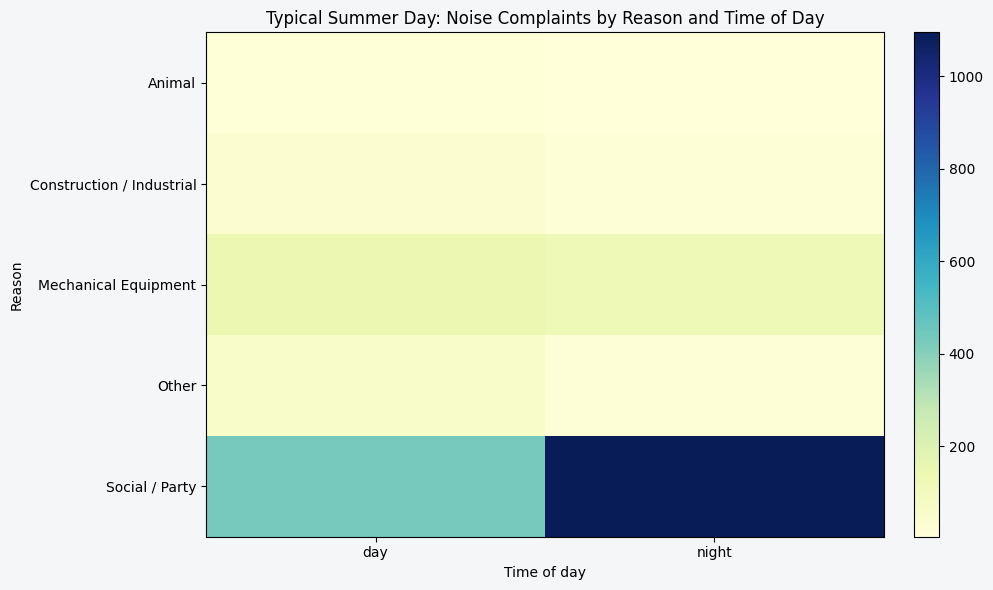

In [7]:
plt.figure(figsize=(10, 6), facecolor="#F5F6F8")
ax = plt.gca()
ax.set_facecolor("#FFFFFF")

im = ax.imshow(
    heatmap_df.values,
    aspect="auto",
    cmap="YlGnBu"
)



ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=0)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

ax.set_title("Typical Summer Day: Noise Complaints by Reason and Time of Day", fontsize=12)
ax.set_xlabel("Time of day")
ax.set_ylabel("Reason")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


### 3) Day-of-week profiles by reason (small multiples)
Panels are sorted from **highest to lowest** typical complaint volume.

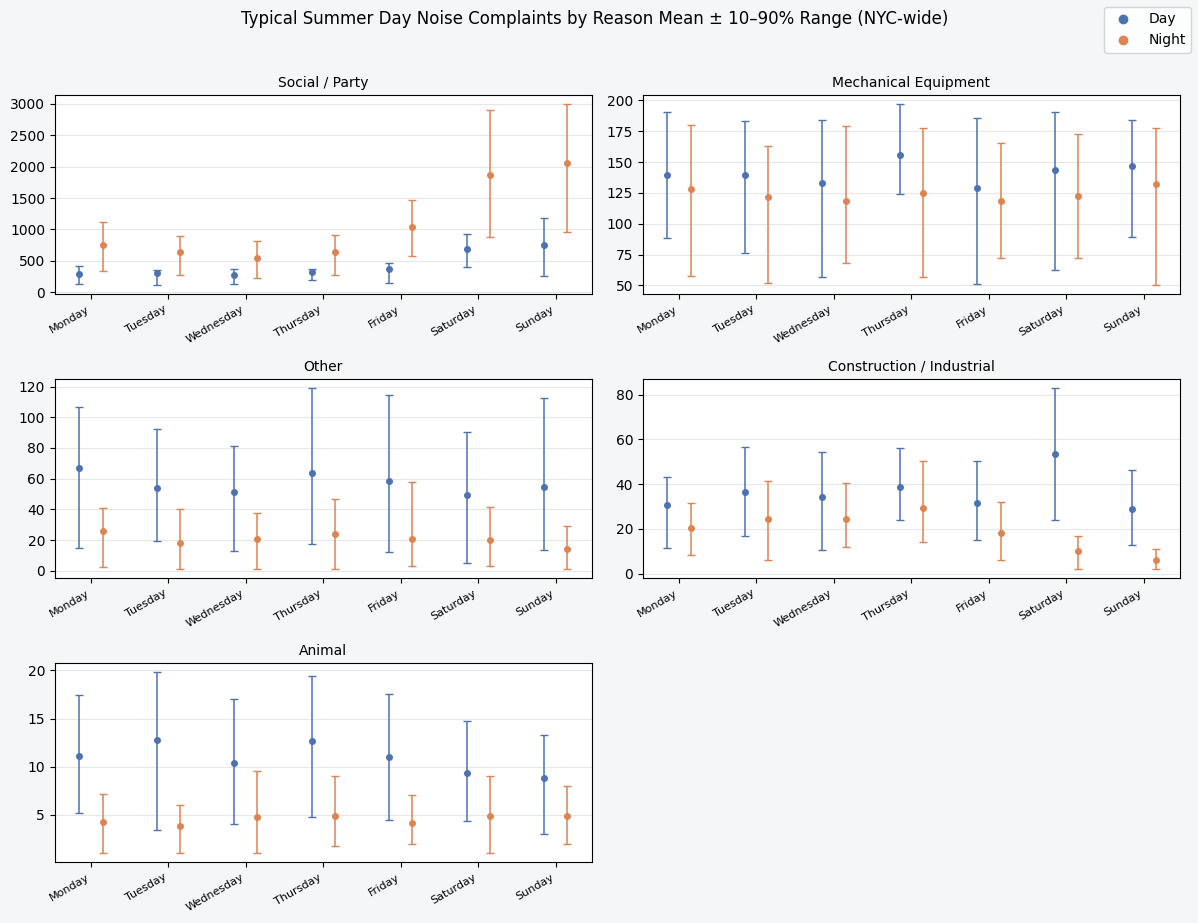

In [8]:
daily = daily_by_reason_time_dow(df_summer)
summary = summarize_dow_profile(daily)

# Sort descriptor groups by overall typical volume (mean across dow & time_of_day)
descriptor_groups = (
    summary.groupby("descriptor_group")["mean"]
           .mean()
           .sort_values(ascending=False)
           .index
           .tolist()
)

n = len(descriptor_groups)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 6, nrows * 3), sharey=False, facecolor="#F5F6F8")
axes = axes.flatten()

colors = {"day": "#4C72B0", "night": "#DD8452"}
offset = {"day": -0.15, "night": 0.15}

for ax, group in zip(axes, descriptor_groups):
    ax.set_facecolor("#FFFFFF")
    g = summary[summary["descriptor_group"] == group]

    for tod in ["day", "night"]:
        d = g[g["time_of_day"] == tod].sort_values("dow")
        if d.empty:
            continue

        yerr = np.vstack([d["mean"] - d["p10"], d["p90"] - d["mean"]])

        ax.errorbar(
            np.arange(len(DOW_ORDER)) + offset[tod],
            d["mean"],
            yerr=yerr,
            fmt="o",
            markersize=4,
            capsize=3,
            elinewidth=1.1,
            color=colors[tod],
            label=tod.capitalize() if ax == axes[0] else None,
        )

    ax.set_title(group, fontsize=10)
    ax.set_xticks(np.arange(len(DOW_ORDER)))
    ax.set_xticklabels(DOW_ORDER, rotation=30, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(descriptor_groups):]:
    ax.axis("off")

fig.suptitle("Typical Summer Day Noise Complaints by Reason Mean ± 10–90% Range (NYC-wide)", fontsize=12, y=1.02)

fig.legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color=colors["day"], label="Day", linestyle=""),
        plt.Line2D([0], [0], marker='o', color=colors["night"], label="Night", linestyle=""),
    ],
    loc="upper right",
)

plt.tight_layout()
plt.show()


### 4) Neighborhood composition: Top/Bottom neighborhoods (day vs night)
These charts show **why** neighborhoods are noisy by stacking complaint reasons.
Neighborhoods are selected using **daytime total** as the ranking criterion.

In [9]:
# Mean daily complaints per neighborhood × reason × time_of_day
daily_nbhd = (
    df_summer
    .groupby([
        df_summer["created_bucket"].dt.date,
        "puma", "nta", "nta_name",
        "descriptor_group",
        "time_of_day"
    ])["complaint_count"]
    .sum()
    .reset_index(name="daily_complaints")
)

mean_tbl = (
    daily_nbhd
    .groupby(["puma", "nta", "nta_name", "descriptor_group", "time_of_day"])["daily_complaints"]
    .mean()
    .reset_index(name="mean_daily_complaints")
)

def plot_stacked_day_night(mean_tbl: pd.DataFrame, selection: pd.DataFrame, title: str, bg_fig="#F5F6F8", bg_ax="#FFFFFF"):
    plot_df = mean_tbl.merge(selection[["puma","nta","nta_name"]], on=["puma","nta","nta_name"], how="inner")

    def make_stacked(time_of_day: str) -> pd.DataFrame:
        return (
            plot_df[plot_df["time_of_day"] == time_of_day]
            .pivot_table(index="nta_name", columns="descriptor_group", values="mean_daily_complaints", aggfunc="sum")
            .fillna(0)
        )

    stack_day = make_stacked("day")
    stack_night = make_stacked("night")

    # Align order using NIGHT totals (ascending so biggest at bottom in barh)
    order = stack_night.sum(axis=1).sort_values(ascending=True).index
    stack_day = stack_day.reindex(order).fillna(0)
    stack_night = stack_night.reindex(order).fillna(0)

    fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True, sharey=True, facecolor=bg_fig)
    for ax in axes:
        ax.set_facecolor(bg_ax)

    stack_day.plot(kind="barh", stacked=True, width=0.85, ax=axes[0], legend=False)
    axes[0].set_title("Day", fontsize=13, weight="semibold")
    axes[0].set_ylabel("Neighborhood (NTA)")
    axes[0].grid(axis="x", alpha=0.3)

    stack_night.plot(kind="barh", stacked=True, width=0.85, ax=axes[1], legend=False)
    axes[1].set_title("Night", fontsize=13, weight="semibold")
    axes[1].set_xlabel("Average noise complaints per summer day")
    axes[1].grid(axis="x", alpha=0.3)

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, title="Complaint reason", bbox_to_anchor=(1.02, 0.5), loc="center left")

    fig.suptitle(title, fontsize=14, y=0.98)
    plt.tight_layout(rect=[0, 0, 0.85, 0.95])
    plt.show()

# Select Top/Bottom neighborhoods by NIGHT total
TOP_N = 10
BOTTOM_N = 10

night_totals = (
    mean_tbl[mean_tbl["time_of_day"] == "night"]
    .groupby(["puma","nta","nta_name"])["mean_daily_complaints"]
    .sum()
    .reset_index(name="night_total")
)

top_sel = night_totals.sort_values("night_total", ascending=False).head(TOP_N)
bottom_sel = night_totals.sort_values("night_total", ascending=True).head(BOTTOM_N)


### Average of Noisiest neighborhoods in Summer of NYC Jun-Aug by time of day and complaints

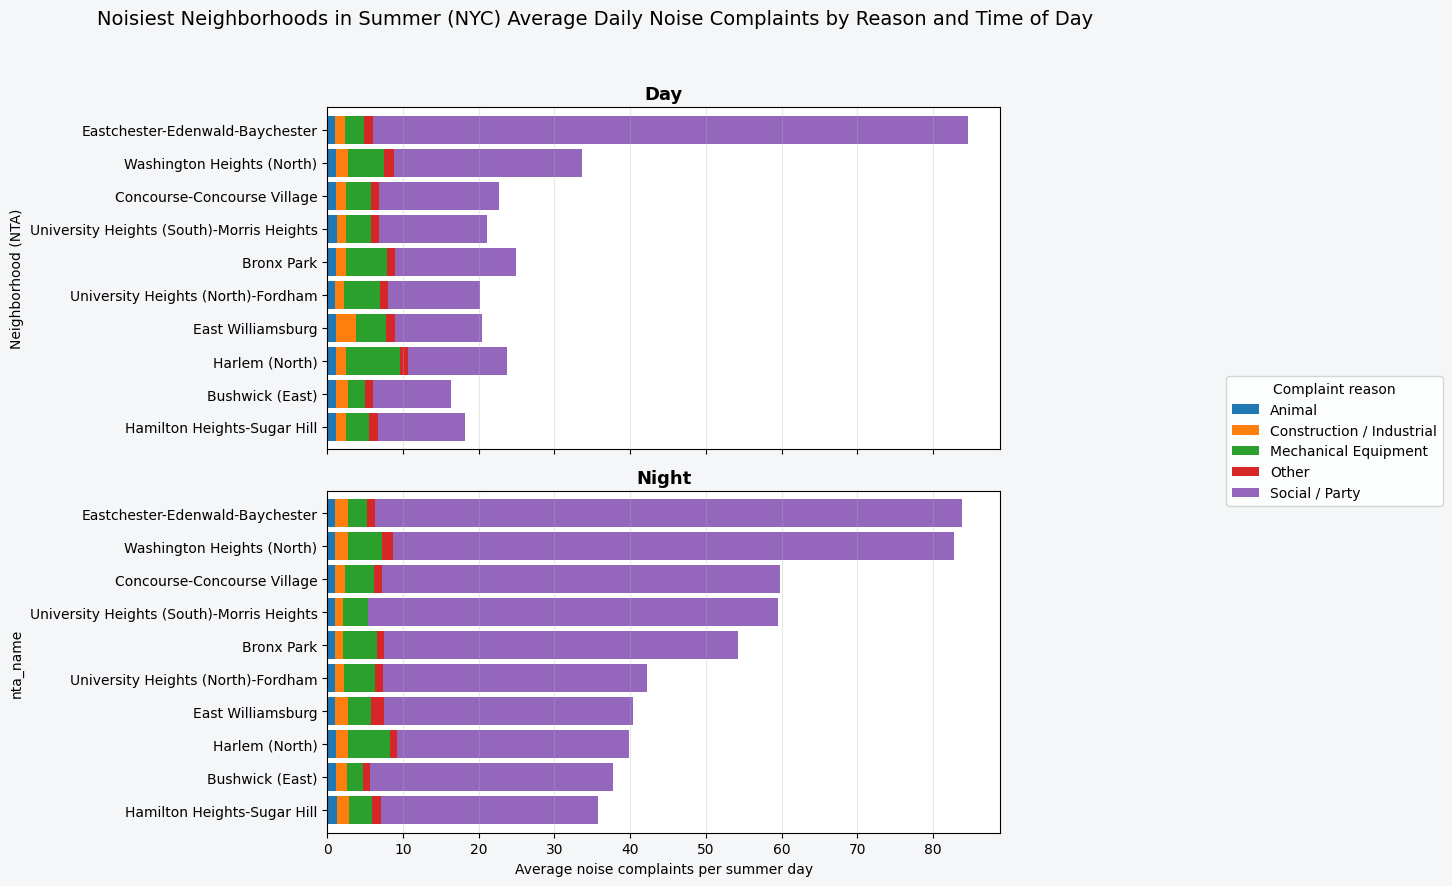

In [10]:

plot_stacked_day_night(
    mean_tbl,
    top_sel,
    title="Noisiest Neighborhoods in Summer (NYC) Average Daily Noise Complaints by Reason and Time of Day",)


### Average of Quietest neighborhoods in Summer of NYC Jun-Aug by time of day and complaints

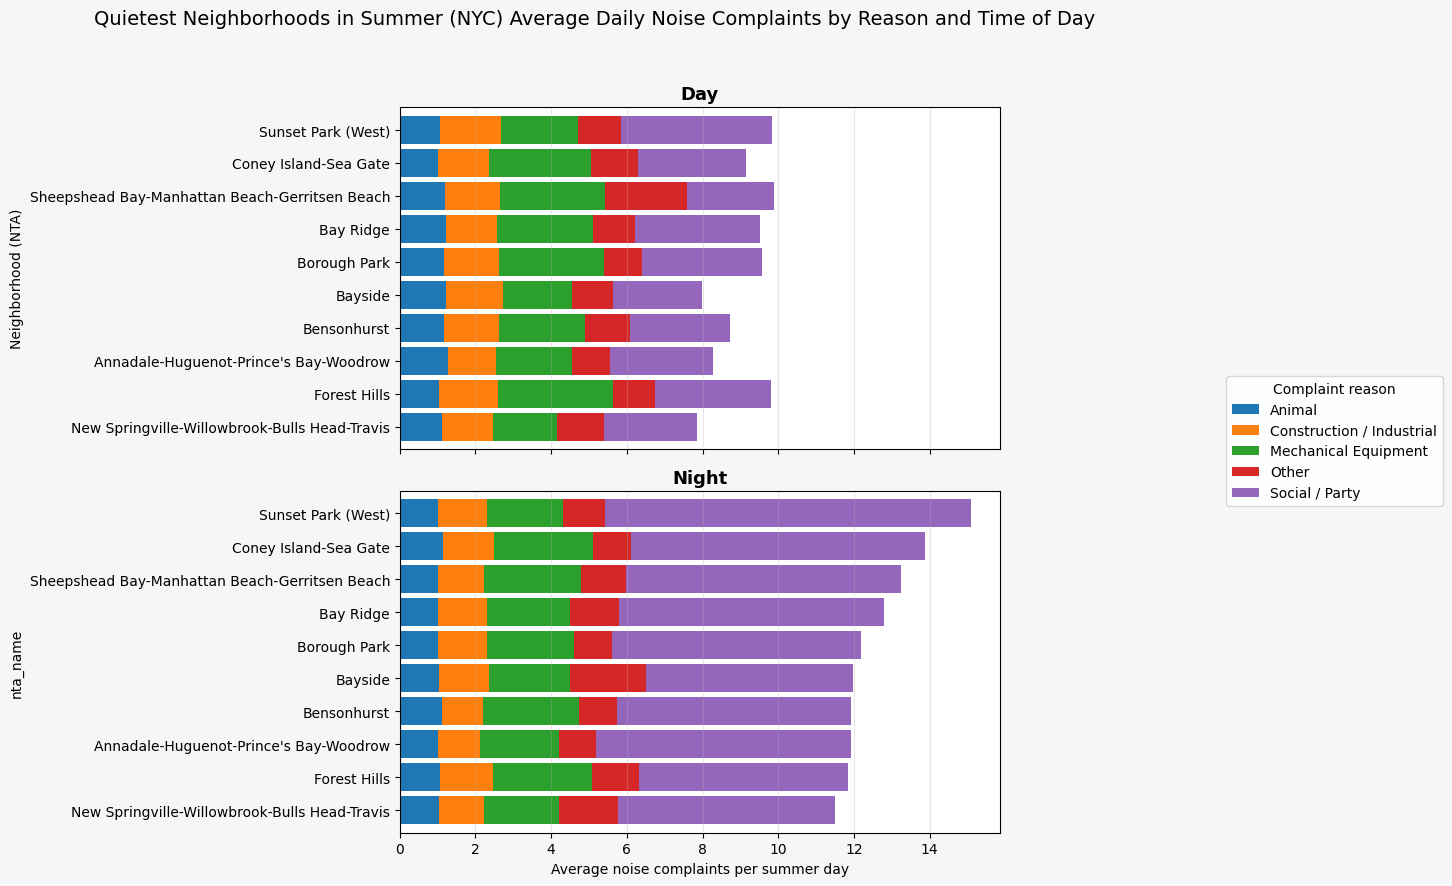

In [11]:

plot_stacked_day_night(
    mean_tbl,
    bottom_sel,
    title="Quietest Neighborhoods in Summer (NYC) Average Daily Noise Complaints by Reason and Time of Day",)
